# Tutorial: Random Directions algorithm x PyPSA

In [1]:
import yaml
import pypsa

from mga4all.examples import create_pypsa_network

import pandas as pd

## 1. Load example PyPSA model

In [2]:
# Load example PyPSA model that the config refers to
n = create_pypsa_network()

INFO:pypsa.network.io:Imported network 'SciGrid-DE' has buses, carriers, generators, lines, loads, storage_units, transformers


In [3]:
# Set the desired solver options
pypsa.options.params.optimize.solver_name = "gurobi"
pypsa.options.params.optimize.solver_options = {
    'Method': 2,  # Use the barrier algorithm
    'Crossover': 0,
}

In [4]:
# Find cost-optimal solution
n.optimize(log_to_console=False);

/tmp/ipykernel_13750/2238090962.py:2: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(log_to_console=False);
Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False
INFO:linopy.io: Writing time: 0.13s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2762135


INFO:gurobipy:Set parameter LicenseID to value 2762135


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Linux Mint 22.2")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 2 physical cores, 4 logical processors, using up to 4 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 688 rows, 296 columns and 1324 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0xd41ae2e6
INFO:gurobipy:Model has 8 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 5e+00]
INFO:gurobipy:  Objective range  [4e+02, 2e+03]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 1e+03]
INFO:gurobipy:
INFO:gurobipy:Presolve removed 124 rows and 332 columns
INFO:gurobipy:Preso

## 2. Generate alternative solutions with random-direction MGA

### 2.1 Load and check MGA configuration

In [5]:
from mga4all.validate import RandomDirectionsConfig

# Load configuration file
with open("../../configs/test_config_random_directions.yaml") as yf:
    test_config = RandomDirectionsConfig.model_validate(yaml.safe_load(yf))

In [6]:
# Check that it reflects the desired setup
test_config

{'config_name': 'random_directions',
 'model_interface': 'pypsa',
 'cost_slack': 0.2,
 'alternatives': 5,
 'spatially_explicit': False,
 'diversified_technologies': ['wind', 'solar', 'gas', 'battery']}

### 2.2 Import algorithm and run

In [7]:
from mga4all.mga_random_directions import random_directions_algorithm

In [8]:
mga_alternatives, mga_spatial_alternatives, mga_weights = random_directions_algorithm(test_config, n)

Index(['line'], dtype='object', name='name')
Index(['line'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - Method: 2
 - Crossover: 0
 - log_to_console: False


Technologies [] not found in the model


INFO:linopy.io: Writing time: 0.14s


Set parameter Username


INFO:gurobipy:Set parameter Username


...

INFO:gurobipy:Set parameter Method to value 2


Set parameter Crossover to value 0


INFO:gurobipy:Set parameter Crossover to value 0


Set parameter LogToConsole to value 0


INFO:gurobipy:Set parameter LogToConsole to value 0
INFO:gurobipy:Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Linux Mint 22.2")
INFO:gurobipy:
INFO:gurobipy:CPU model: Intel(R) Core(TM) i5-6300U CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2]
INFO:gurobipy:Thread count: 2 physical cores, 4 logical processors, using up to 4 threads
INFO:gurobipy:
INFO:gurobipy:Non-default parameters:
INFO:gurobipy:Method  2
INFO:gurobipy:Crossover  0
INFO:gurobipy:LogToConsole  0
INFO:gurobipy:
INFO:gurobipy:Optimize a model with 689 rows, 296 columns and 1332 nonzeros (Min)
INFO:gurobipy:Model fingerprint: 0xa26117f4
INFO:gurobipy:Model has 7 linear objective coefficients
INFO:gurobipy:Coefficient statistics:
INFO:gurobipy:  Matrix range     [4e-02, 2e+03]
INFO:gurobipy:  Objective range  [2e-02, 3e-01]
INFO:gurobipy:  Bounds range     [0e+00, 0e+00]
INFO:gurobipy:  RHS range        [2e+02, 7e+05]
INFO:gurobipy:
INFO:gurobipy:Presolve removed 124 rows and 334 columns
INFO:gurobipy:Preso

### 2.3 Inspect the alternatives

In [9]:
mga_total_capacities = pd.concat((
    pd.DataFrame(mga_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

mga_spatial_capacities = pd.concat((
    pd.DataFrame(mga_spatial_alternatives[x]).fillna(0).round(2).sum(axis=1) for x in mga_alternatives
), axis=1)

<Axes: >

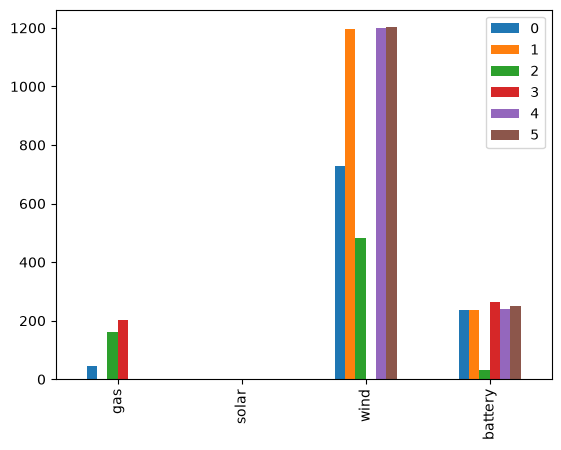

In [10]:
mga_total_capacities.plot.bar()

<Axes: >

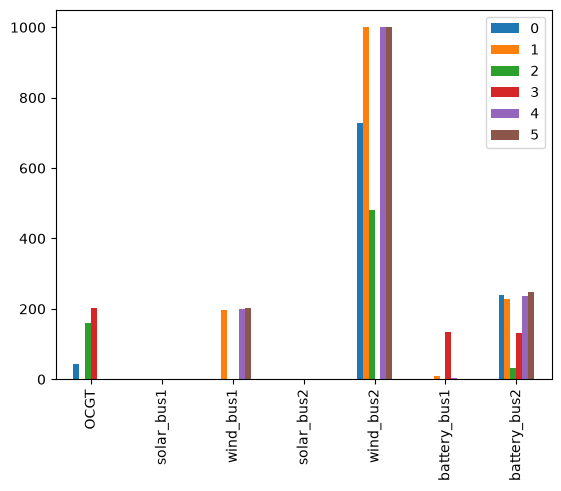

In [11]:
mga_spatial_capacities.plot.bar()

In [12]:
mga_weights = pd.concat((
    pd.DataFrame(mga_weights[x]).fillna(0).round(2).sum(axis=1) for x in mga_weights
), axis=1)
mga_weights

,0,1,2,3,4,5
gas,0.57,0.70,0.06,0.22,0.17,0
solar,-0.18,0.87,-0.13,0.51,-0.14,0
wind,-0.43,0.00,0.40,-0.92,-0.35,0
battery,0.91,0.72,-0.49,0.88,-0.02,0
